### Task-1: Dataset Generation

In [21]:
import numpy as np
import random

random.seed(42)
np.random.seed(42)

def generate_sequence(max_repeats=6):
    """
    Generates sequence of the form:
    a a ... b b ... EOS
    where number of a's = number of b's
    """
    k = random.randint(1, max_repeats)
    sequence = ['a'] * k + ['b'] * k + ['EOS']
    return sequence

num_sequences = 1000
dataset = [generate_sequence() for _ in range(num_sequences)]

print("Sample sequence:")
print(dataset[0])

Sample sequence:
['a', 'a', 'a', 'a', 'a', 'a', 'b', 'b', 'b', 'b', 'b', 'b', 'EOS']


### Task-2: Token Representation

In [22]:
vocab = set()
for seq in dataset:
    vocab.update(seq)

vocab.add('UNK')
vocab_list = sorted(list(vocab))

word_to_idx = {word: idx for idx, word in enumerate(vocab_list)}
idx_to_word = {idx: word for word, idx in word_to_idx.items()}

print("Vocabulary:", word_to_idx)
print("Vocabulary size:", len(word_to_idx))
print("Total number of sequences:", len(dataset))

Vocabulary: {'EOS': 0, 'UNK': 1, 'a': 2, 'b': 3}
Vocabulary size: 4
Total number of sequences: 1000


### Task-3: Train-Test Split

In [23]:
split_index = int(0.8 * len(dataset))

train_sequences = dataset[:split_index]
test_sequences = dataset[split_index:]

print("Training sequences:", len(train_sequences))
print("Testing sequences:", len(test_sequences))

def create_input_target_pairs(sequences):
    inputs = []
    targets = []

    for seq in sequences:
        input_seq = seq[:-1]  
        target_seq = seq[1:]   

        inputs.append(input_seq)
        targets.append(target_seq)

    return inputs, targets

train_inputs, train_targets = create_input_target_pairs(train_sequences)
test_inputs, test_targets = create_input_target_pairs(test_sequences)

print("\nSample processed sequence:")
print("Input :", train_inputs[0])
print("Target:", train_targets[0])

Training sequences: 800
Testing sequences: 200

Sample processed sequence:
Input : ['a', 'a', 'a', 'a', 'a', 'a', 'b', 'b', 'b', 'b', 'b', 'b']
Target: ['a', 'a', 'a', 'a', 'a', 'b', 'b', 'b', 'b', 'b', 'b', 'EOS']


### Task-4: One-Hot Encoding

In [24]:
def one_hot_encode(token, vocab_size):
    vec = np.zeros((vocab_size, 1))
    idx = word_to_idx.get(token, word_to_idx['UNK'])
    vec[idx] = 1
    return vec

def encode_sequence(sequence):
    encoded = []
    vocab_size = len(word_to_idx)

    for token in sequence:
        encoded.append(one_hot_encode(token, vocab_size))

    return np.array(encoded)

encoded_token = one_hot_encode('a', len(word_to_idx))
encoded_sequence = encode_sequence(train_inputs[0])

print("Encoded token shape:", encoded_token.shape)
print("Encoded sequence shape:", encoded_sequence.shape)

Encoded token shape: (4, 1)
Encoded sequence shape: (12, 4, 1)


### Task-5: RNN Implementation

In [25]:
vocab_size = len(word_to_idx)
hidden_size = 32
learning_rate = 0.02

Wxh = np.random.randn(hidden_size, vocab_size) * 0.01
Whh = np.random.randn(hidden_size, hidden_size) * 0.01
Why = np.random.randn(vocab_size, hidden_size) * 0.01

bh = np.zeros((hidden_size, 1))
by = np.zeros((vocab_size, 1))

def softmax(x):
    e = np.exp(x - np.max(x))
    return e / np.sum(e, axis=0, keepdims=True)

def rnn_forward(inputs, targets, h_prev):
    xs, hs, ys, ps = {}, {}, {}, {}
    hs[-1] = h_prev
    loss = 0

    for t in range(len(inputs)):
        xs[t] = one_hot_encode(inputs[t], vocab_size)

        hs[t] = np.tanh(
            np.dot(Wxh, xs[t]) +
            np.dot(Whh, hs[t-1]) +
            bh
        )

        ys[t] = np.dot(Why, hs[t]) + by
        ps[t] = softmax(ys[t])

        target_idx = word_to_idx[targets[t]]
        loss += -np.log(ps[t][target_idx, 0])

    cache = (xs, hs, ps)
    return loss, cache, hs[len(inputs)-1]

def rnn_backward(inputs, targets, cache, h_prev, clip=True):
    xs, hs, ps = cache

    dWxh = np.zeros_like(Wxh)
    dWhh = np.zeros_like(Whh)
    dWhy = np.zeros_like(Why)
    dbh = np.zeros_like(bh)
    dby = np.zeros_like(by)

    dh_next = np.zeros_like(hs[0])

    for t in reversed(range(len(inputs))):
        dy = np.copy(ps[t])
        target_idx = word_to_idx[targets[t]]
        dy[target_idx] -= 1

        dWhy += np.dot(dy, hs[t].T)
        dby += dy

        dh = np.dot(Why.T, dy) + dh_next
        dh_raw = (1 - hs[t] ** 2) * dh

        dbh += dh_raw
        dWxh += np.dot(dh_raw, xs[t].T)
        dWhh += np.dot(dh_raw, hs[t-1].T)

        dh_next = np.dot(Whh.T, dh_raw)

    if clip:
        for dparam in [dWxh, dWhh, dWhy, dbh, dby]:
            np.clip(dparam, -5, 5, out=dparam)

    return dWxh, dWhh, dWhy, dbh, dby

def update_parameters(grads):
    global Wxh, Whh, Why, bh, by

    dWxh, dWhh, dWhy, dbh, dby = grads

    Wxh -= learning_rate * dWxh
    Whh -= learning_rate * dWhh
    Why -= learning_rate * dWhy
    bh  -= learning_rate * dbh
    by  -= learning_rate * dby

### Task-6: Training

In [26]:
def run_training(train_inputs, train_targets, epochs=30, use_clipping=True):
    losses = []

    for epoch in range(epochs):
        total_loss = 0

        for inputs, targets in zip(train_inputs, train_targets):
            h_prev = np.zeros((hidden_size, 1))

            loss, cache, _ = rnn_forward(inputs, targets, h_prev)
            total_loss += loss

            grads = rnn_backward(inputs, targets, cache, h_prev,clip=use_clipping)
            update_parameters(grads)

        avg_loss = total_loss / len(train_inputs)
        losses.append(avg_loss)

        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

    return losses

def reset_parameters():
    global Wxh, Whh, Why, bh, by

    Wxh = np.random.randn(hidden_size, vocab_size) * 0.01
    Whh = np.random.randn(hidden_size, hidden_size) * 0.01
    Why = np.random.randn(vocab_size, hidden_size) * 0.01
    bh = np.zeros((hidden_size, 1))
    by = np.zeros((vocab_size, 1))


===== Training WITHOUT Gradient Clipping =====
Epoch 1/30, Loss: 4.4781
Epoch 2/30, Loss: 3.6105
Epoch 3/30, Loss: 2.9050
Epoch 4/30, Loss: 1.9790
Epoch 5/30, Loss: 1.8855
Epoch 6/30, Loss: 1.8717
Epoch 7/30, Loss: 1.8646
Epoch 8/30, Loss: 1.8600
Epoch 9/30, Loss: 1.8567
Epoch 10/30, Loss: 1.9776
Epoch 11/30, Loss: 1.9220
Epoch 12/30, Loss: 1.8557
Epoch 13/30, Loss: 1.8518
Epoch 14/30, Loss: 1.8497
Epoch 15/30, Loss: 1.8481
Epoch 16/30, Loss: 1.8468
Epoch 17/30, Loss: 1.8457
Epoch 18/30, Loss: 1.8448
Epoch 19/30, Loss: 1.8440
Epoch 20/30, Loss: 1.8433
Epoch 21/30, Loss: 1.8427
Epoch 22/30, Loss: 1.8421
Epoch 23/30, Loss: 1.8416
Epoch 24/30, Loss: 1.8412
Epoch 25/30, Loss: 1.8407
Epoch 26/30, Loss: 2.3577
Epoch 27/30, Loss: 1.9106
Epoch 28/30, Loss: 1.8739
Epoch 29/30, Loss: 1.8655
Epoch 30/30, Loss: 1.8601

===== Training WITH Gradient Clipping =====
Epoch 1/30, Loss: 4.3050
Epoch 2/30, Loss: 3.6282
Epoch 3/30, Loss: 2.7786
Epoch 4/30, Loss: 2.0508
Epoch 5/30, Loss: 1.9912
Epoch 6/30,

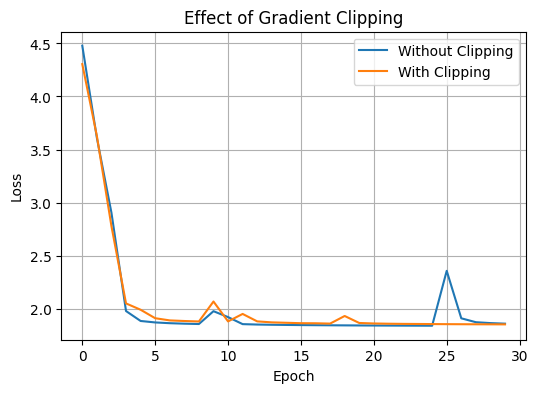

In [27]:
reset_parameters()
print("\n===== Training WITHOUT Gradient Clipping =====")

loss_no_clip = run_training(
    train_inputs,
    train_targets,
    epochs=30,
    use_clipping=False
)
reset_parameters()
print("\n===== Training WITH Gradient Clipping =====")

loss_clip = run_training(
    train_inputs,
    train_targets,
    epochs=30,
    use_clipping=True
)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(loss_no_clip, label="Without Clipping")
plt.plot(loss_clip, label="With Clipping")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Effect of Gradient Clipping")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
test_loss = 0

for inputs, targets in zip(test_inputs, test_targets):
    h_prev = np.zeros((hidden_size, 1)) 
    loss, _, _ = rnn_forward(inputs, targets, h_prev)
    test_loss += loss

avg_test_loss = test_loss / len(test_inputs)
print("\nTest Loss:", avg_test_loss)

def sequence_accuracy(inputs_list, targets_list):
    correct = 0
    total = 0

    for inputs, targets in zip(inputs_list, targets_list):
        h = np.zeros((hidden_size, 1))

        for t in range(len(inputs)):
            x = one_hot_encode(inputs[t], vocab_size)
            h = np.tanh(np.dot(Wxh, x) + np.dot(Whh, h) + bh)
            y = np.dot(Why, h) + by
            p = softmax(y)

            pred_idx = np.argmax(p)
            true_idx = word_to_idx[targets[t]]

            if pred_idx == true_idx:
                correct += 1
            total += 1

    return correct / total


train_acc = sequence_accuracy(train_inputs, train_targets)
test_acc = sequence_accuracy(test_inputs, test_targets)

print(f"Train Accuracy: {train_acc*100:.2f}%")
print(f"Test Accuracy : {test_acc*100:.2f}%")

def sample_sequence(start_token='a', max_len=20):
    h = np.zeros((hidden_size, 1))
    token = start_token
    generated = [token]

    for _ in range(max_len):
        x = one_hot_encode(token, vocab_size)
        h = np.tanh(np.dot(Wxh, x) + np.dot(Whh, h) + bh)
        y = np.dot(Why, h) + by
        p = softmax(y)

        idx = np.argmax(p)
        token = idx_to_word[idx]
        generated.append(token)

        if token == 'EOS':
            break

    return generated

def print_predictions(inputs_list, targets_list, num_sequences=5):
    print("\nSample Predictions:\n")

    for i in range(num_sequences):
        inputs = inputs_list[i]
        targets = targets_list[i]

        h = np.zeros((hidden_size, 1))

        print(f"Sequence {i+1}")

        for t in range(len(inputs)):
            x = one_hot_encode(inputs[t], vocab_size)

            h = np.tanh(np.dot(Wxh, x) + np.dot(Whh, h) + bh)
            y = np.dot(Why, h) + by
            p = softmax(y)

            pred_idx = np.argmax(p)
            pred_token = idx_to_word[pred_idx]

            true_token = targets[t]

            print(f"Input: {inputs[t]}  |  True: {true_token}  |  Predicted: {pred_token}")

        print("-" * 40)

print_predictions(test_inputs, test_targets)
print("\nGenerated sequence example:")
print(sample_sequence())


Test Loss: 1.8285688401517524
Train Accuracy: 88.19%
Test Accuracy : 88.40%

Sample Predictions:

Sequence 1
Input: a  |  True: a  |  Predicted: a
Input: a  |  True: a  |  Predicted: a
Input: a  |  True: b  |  Predicted: a
Input: b  |  True: b  |  Predicted: b
Input: b  |  True: b  |  Predicted: b
Input: b  |  True: EOS  |  Predicted: EOS
----------------------------------------
Sequence 2
Input: a  |  True: a  |  Predicted: a
Input: a  |  True: b  |  Predicted: a
Input: b  |  True: b  |  Predicted: b
Input: b  |  True: EOS  |  Predicted: EOS
----------------------------------------
Sequence 3
Input: a  |  True: a  |  Predicted: a
Input: a  |  True: a  |  Predicted: a
Input: a  |  True: a  |  Predicted: a
Input: a  |  True: a  |  Predicted: a
Input: a  |  True: b  |  Predicted: a
Input: b  |  True: b  |  Predicted: b
Input: b  |  True: b  |  Predicted: b
Input: b  |  True: b  |  Predicted: b
Input: b  |  True: b  |  Predicted: b
Input: b  |  True: EOS  |  Predicted: EOS
--------------

## Problem 2: RNN for Time Series Prediction (Sine Wave)

### Task-1: Generate sine wave dataset.

First 10 values of sine wave:
[0.         0.02001868 0.04002934 0.06002396 0.07999452 0.09993302
 0.11983146 0.13968188 0.15947632 0.17920684]


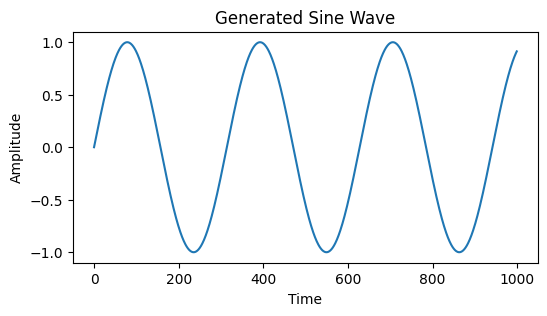

In [29]:
import numpy as np
import matplotlib.pyplot as plt

time_steps = 1000
x = np.linspace(0, 20, time_steps)
sine_wave = np.sin(x)

print("First 10 values of sine wave:")
print(sine_wave[:10])

# Plot
plt.figure(figsize=(6,3))
plt.plot(sine_wave)
plt.title("Generated Sine Wave")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

### Task-2: Create input sequences of length 50.

In [30]:
window_size = 50
train_size = 750

train_series = sine_wave[:train_size]
test_series  = sine_wave[train_size - window_size:]

def create_windows(series, window_size):
    X = []
    Y = []

    for i in range(len(series) - window_size):
        X.append(series[i:i + window_size])
        Y.append(series[i + window_size])

    return np.array(X), np.array(Y)

X_train, Y_train = create_windows(train_series, window_size)
X_test, Y_test = create_windows(test_series, window_size)

print("Train windows:", X_train.shape)
print("Test windows :", X_test.shape)

Train windows: (700, 50)
Test windows : (250, 50)


### Task-3: Implement RNN for regression.

In [31]:
X_train_rnn = X_train.reshape(X_train.shape[0], window_size, 1)
Y_train_rnn = Y_train.reshape(-1, 1)

X_test_rnn = X_test.reshape(X_test.shape[0], window_size, 1)
Y_test_rnn = Y_test.reshape(-1, 1)

input_size = 1
hidden_size = 32
output_size = 1
learning_rate = 0.005

Wxh = np.random.randn(hidden_size, input_size) * 0.1
Whh = np.random.randn(hidden_size, hidden_size) * 0.1
Why = np.random.randn(output_size, hidden_size) * 0.1

bh = np.zeros((hidden_size, 1))
by = np.zeros((output_size, 1))

def rnn_forward_regression(sequence, target):
    hs = {}
    hs[-1] = np.zeros((hidden_size, 1))

    for t in range(len(sequence)):
        x_t = sequence[t].reshape(1, 1)
        hs[t] = np.tanh(
            np.dot(Wxh, x_t) +
            np.dot(Whh, hs[t-1]) +
            bh
        )

    y_pred = np.dot(Why, hs[len(sequence)-1]) + by
    loss = (y_pred - target.reshape(1,1))**2

    cache = (hs, sequence, target, y_pred)
    return loss.item(), cache

### Task-4: Train the model.

In [32]:
def rnn_backward_regression(cache):
    global Wxh, Whh, Why, bh, by

    hs, sequence, target, y_pred = cache

    dWxh = np.zeros_like(Wxh)
    dWhh = np.zeros_like(Whh)
    dWhy = np.zeros_like(Why)
    dbh = np.zeros_like(bh)
    dby = np.zeros_like(by)

    dy = 2 * (y_pred - target.reshape(1,1))
    dWhy += np.dot(dy, hs[len(sequence)-1].T)
    dby += dy

    dh_next = np.dot(Why.T, dy)
    for t in reversed(range(len(sequence))):
        dh = dh_next
        h_raw = (1 - hs[t]**2) * dh

        x_t = sequence[t].reshape(1,1)

        dWxh += np.dot(h_raw, x_t.T)
        dWhh += np.dot(h_raw, hs[t-1].T)
        dbh += h_raw

        dh_next = np.dot(Whh.T, h_raw)
        
    for dparam in [dWxh, dWhh, dWhy, dbh, dby]:
        np.clip(dparam, -5, 5, out=dparam)

    return dWxh, dWhh, dWhy, dbh, dby

def update_parameters_regression(grads):
    global Wxh, Whh, Why, bh, by

    dWxh, dWhh, dWhy, dbh, dby = grads

    Wxh -= learning_rate * dWxh
    Whh -= learning_rate * dWhh
    Why -= learning_rate * dWhy
    bh  -= learning_rate * dbh
    by  -= learning_rate * dby
    
epochs = 100

for epoch in range(epochs):
    total_loss = 0

    for i in range(len(X_train_rnn)):
        seq = X_train_rnn[i]
        target = Y_train_rnn[i]

        loss, cache = rnn_forward_regression(seq, target)
        total_loss += loss

        grads = rnn_backward_regression(cache)
        update_parameters_regression(grads)

    avg_loss = total_loss / len(X_train_rnn)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")

Epoch 1/100, Loss: 0.066062
Epoch 2/100, Loss: 0.001095
Epoch 3/100, Loss: 0.000985
Epoch 4/100, Loss: 0.000939
Epoch 5/100, Loss: 0.000897
Epoch 6/100, Loss: 0.000859
Epoch 7/100, Loss: 0.000824
Epoch 8/100, Loss: 0.000792
Epoch 9/100, Loss: 0.000762
Epoch 10/100, Loss: 0.000734
Epoch 11/100, Loss: 0.000708
Epoch 12/100, Loss: 0.000683
Epoch 13/100, Loss: 0.000660
Epoch 14/100, Loss: 0.000639
Epoch 15/100, Loss: 0.000618
Epoch 16/100, Loss: 0.000599
Epoch 17/100, Loss: 0.000580
Epoch 18/100, Loss: 0.000562
Epoch 19/100, Loss: 0.000545
Epoch 20/100, Loss: 0.000529
Epoch 21/100, Loss: 0.000513
Epoch 22/100, Loss: 0.000498
Epoch 23/100, Loss: 0.000484
Epoch 24/100, Loss: 0.000470
Epoch 25/100, Loss: 0.000457
Epoch 26/100, Loss: 0.000444
Epoch 27/100, Loss: 0.000431
Epoch 28/100, Loss: 0.000419
Epoch 29/100, Loss: 0.000407
Epoch 30/100, Loss: 0.000395
Epoch 31/100, Loss: 0.000384
Epoch 32/100, Loss: 0.000373
Epoch 33/100, Loss: 0.000362
Epoch 34/100, Loss: 0.000352
Epoch 35/100, Loss: 0.0

### Task-5: Predict the next value.

In [33]:
def predict_next_value(sequence):
    h = np.zeros((hidden_size, 1))

    for t in range(len(sequence)):
        x_t = sequence[t].reshape(1,1)
        h = np.tanh(
            np.dot(Wxh, x_t) +
            np.dot(Whh, h) +
            bh
        )

    y_pred = np.dot(Why, h) + by
    return y_pred.item()

### Task-6: Compare predicted value with actual sine value. 

In [34]:
test_preds = []
test_actuals = []

for i in range(len(X_test_rnn)):
    pred = predict_next_value(X_test_rnn[i])
    test_preds.append(pred)
    test_actuals.append(Y_test_rnn[i].item())

test_mse = np.mean((np.array(test_preds) - np.array(test_actuals))**2)

print("\nTest MSE:", test_mse)


Test MSE: 0.0001248900715696932


### Task-7: Plot actual vs predicted output.

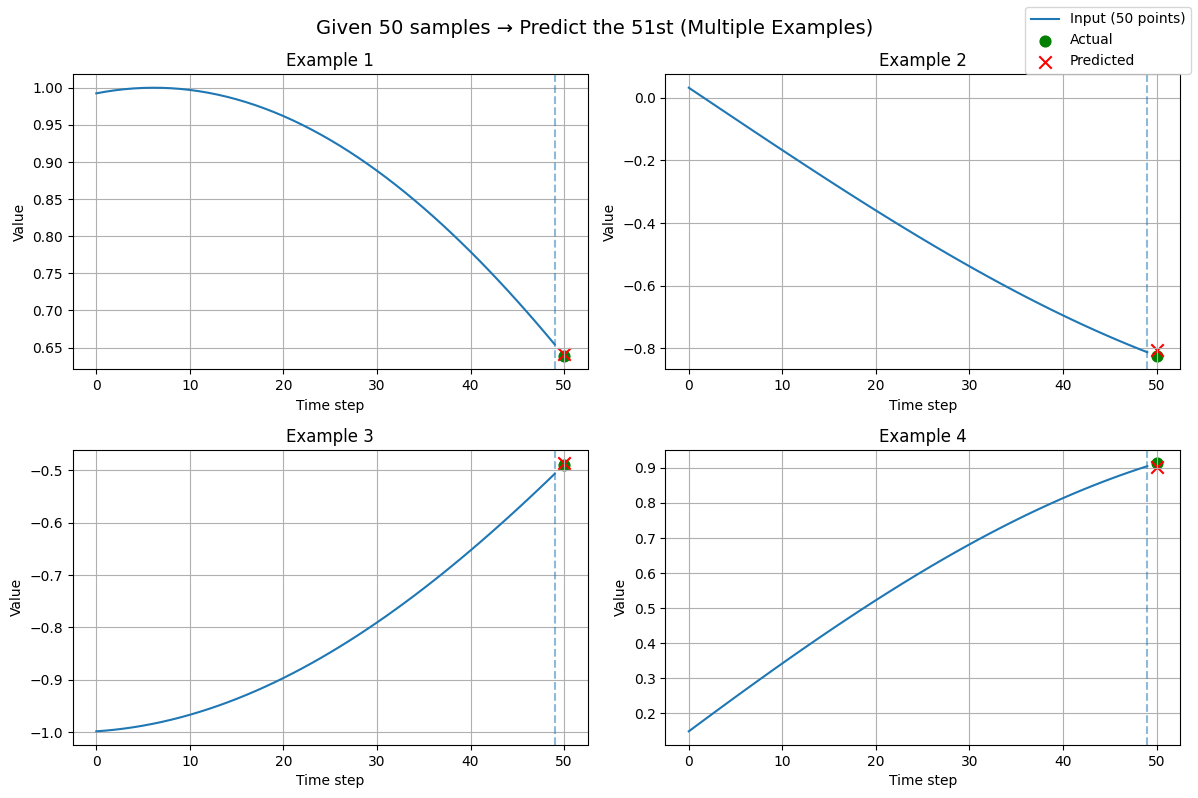

In [35]:
num_examples = 4
indices = np.linspace(0, len(X_test)-1, num_examples, dtype=int)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for k, idx in enumerate(indices):
    ax = axes[k]

    input_window = X_test[idx]
    true_next = Y_test[idx]
    pred_next = predict_next_value(X_test_rnn[idx])

    x_input = np.arange(window_size)
    x_next = window_size

    ax.plot(x_input, input_window, label="Input (50 points)")
    ax.scatter(x_next, true_next,
               color="green", s=60, label="Actual")

    ax.scatter(x_next, pred_next,
               color="red", marker="x", s=80,
               label="Predicted")

    ax.axvline(window_size-1, linestyle="--", alpha=0.5)
    ax.set_title(f"Example {k+1}")
    ax.set_xlabel("Time step")
    ax.set_ylabel("Value")
    ax.grid(True)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")

plt.suptitle("Given 50 samples → Predict the 51st (Multiple Examples)", fontsize=14)
plt.tight_layout()
plt.show()